# 05. Классификация: анализ результатов (локальный режим)

**Цель:** воспроизвести ключевые графики для диплома без загрузки эмбеддингов — только из CSV-файлов в `results/`.

**Что строится:**
- Тепловая карта Balanced Accuracy (MARLIN vit_base: стратегии × классификаторы)
- Сравнение стратегий агрегирования (bar chart)
- Стабильность по фолдам (bar + error bars на основе std)
- Сравнение всех моделей: лицевые vs общие энкодеры
- Итоговая таблица топ конфигураций

---

## 0. Зависимости и настройки

In [5]:
!pip install -q pandas numpy matplotlib seaborn

In [6]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    "figure.dpi":        120,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Папка для сохранения графиков — подстраивается под среду
try:
    from google.colab import drive  # noqa: F401
    _in_colab = True
except ImportError:
    _in_colab = False

if _in_colab:
    FIGURES_DIR = Path("/content/figures")
else:
    _cwd = Path().resolve()
    _root = next((p for p in [_cwd, _cwd.parent] if (p / "figures").exists()), _cwd)
    FIGURES_DIR = _root / "figures"

FIGURES_DIR.mkdir(exist_ok=True)
print(f"Графики будут сохранены в: {FIGURES_DIR}")
print("Готово.")

Графики будут сохранены в: /content/figures
Готово.


## 1. Данные (встроены в ноутбук)

Все результаты экспериментов вшиты прямо в ячейку — ноутбук работает на любой среде (Colab, Kaggle, локально) без доступа к файлам.

In [7]:
marlin_base = pd.read_csv(io.StringIO("""features,classifier,bal_acc,std,auc
std_only,RF,0.6675518341307815,0.19621671871916213,0.481638418079096
std_only,SVM_RBF,0.6179163818637503,0.11469599113802464,0.5237288135593221
mean_std,RF,0.5927044884939622,0.19870704570003195,0.47895480225988696
mean_std,LR,0.5870950102529049,0.23978047577261447,0.4497175141242938
std_only,LR,0.5819024834814308,0.229463334067879,0.5398305084745763
std_only,SVM_lin,0.5736887673729779,0.23318542038138707,0.4987288135593221
mean_std,SVM_lin,0.5711540214171793,0.24443718891359922,0.44378531073446326
mean_only,SVM_lin,0.547639553429027,0.17653520493850655,0.4018361581920904
mean_std,SVM_RBF,0.5359261790840739,0.12714814687582213,0.4588983050847457
mean_only,LR,0.531593757120073,0.17450281552154281,0.37768361581920906
mean_only,RF,0.46154704944178626,0.1102340181194938,0.3721751412429379
mean_only,SVM_RBF,0.4500250626566416,0.14586434729401399,0.39237288135593223
"""))

marlin_large = pd.read_csv(io.StringIO("""classifier,encoder,ba,ba_std,f1,auc,mcc
RF,vit_large,0.4826441102756892,0.03094978071937013,0.34702954146700904,0.5997502848029164,-0.05873065845689773
LR,vit_large,0.6113362952836636,0.07996622081672426,0.5485905189476888,0.6836700843016633,0.2224762694379263
SVM_Lin,vit_large,0.6201013898382319,0.13666989302594507,0.5830656975433852,0.6763991797676008,0.24472828389507256
SVM_RBF,vit_large,0.5,0.0,0.32917915913780094,0.589902939166097,0.0
"""))

general_enc = pd.read_csv(io.StringIO("""model,best_clf,ba,ba_std,f1,auc,mcc
VideoMAE-large,LR,0.6362087035771247,0.10911859195525453,0.60434229390681,0.685274550011392,0.2770406381452714
TimeSformer,LR,0.55045340624288,0.16423476780174023,0.5032284505968716,0.43444702665755297,0.0801225695162541
ViViT,SVM_Lin,0.5718124857598542,0.14822320354083365,0.5121829697880382,0.5351565276828435,0.1300449770108464
"""))

videomae_b = pd.read_csv(io.StringIO("""model,classifier,ba,ba_std,f1,auc,mcc
VideoMAE-base,RF,0.5054032809295967,0.09827007729039906,0.414477889260498,0.5705709728867624,0.0049157578678001804
VideoMAE-base,LR,0.6090282524493051,0.15611271209604513,0.5385909767831965,0.6326552745500115,0.23992348854443946
VideoMAE-base,SVM_Lin,0.6206949191159717,0.19679085699777535,0.5493669374104156,0.6605363408521303,0.2505698615297938
VideoMAE-base,SVM_RBF,0.4659774436090225,0.047573476083429496,0.32096942095832015,0.5488758259284576,-0.1039102185935938
"""))

all_models = pd.read_csv(io.StringIO("""Модель,Тип,dim,BA,AUC,F1
MARLIN vit_base,Лицевой,768,0.668,0.628,0.625
VideoMAE-large,Общий,1024,0.6362087035771247,0.685274550011392,0.60434229390681
VideoMAE-base,Общий,768,0.621,0.661,0.549
ViViT,Общий,768,0.5718124857598542,0.5351565276828435,0.5121829697880382
TimeSformer,Общий,768,0.55045340624288,0.43444702665755297,0.5032284505968716
MARLIN vit_small,Лицевой,384,0.487,0.544,0.487
"""))

print("=== marlin_vit_base_results ===")
print(marlin_base.to_string(index=False))
print(f"\nВсего конфигураций: {len(marlin_base)}")

=== marlin_vit_base_results ===
 features classifier  bal_acc      std      auc
 std_only         RF 0.667552 0.196217 0.481638
 std_only    SVM_RBF 0.617916 0.114696 0.523729
 mean_std         RF 0.592704 0.198707 0.478955
 mean_std         LR 0.587095 0.239780 0.449718
 std_only         LR 0.581902 0.229463 0.539831
 std_only    SVM_lin 0.573689 0.233185 0.498729
 mean_std    SVM_lin 0.571154 0.244437 0.443785
mean_only    SVM_lin 0.547640 0.176535 0.401836
 mean_std    SVM_RBF 0.535926 0.127148 0.458898
mean_only         LR 0.531594 0.174503 0.377684
mean_only         RF 0.461547 0.110234 0.372175
mean_only    SVM_RBF 0.450025 0.145864 0.392373

Всего конфигураций: 12


## 2. Тепловая карта Balanced Accuracy

MARLIN vit_base: стратегии агрегирования × классификаторы.

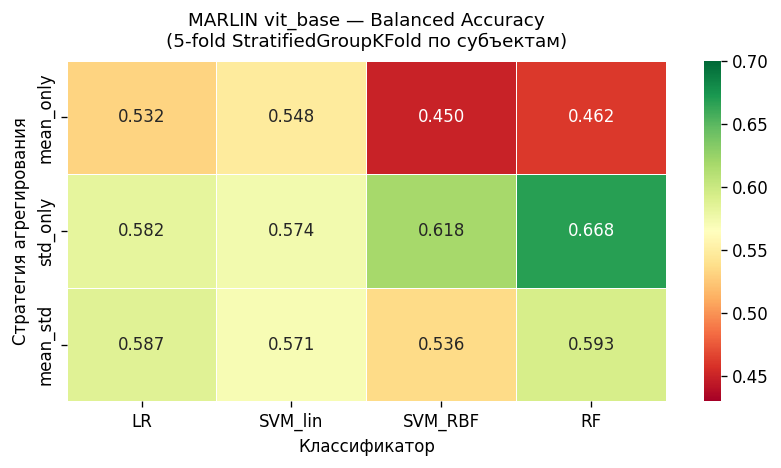

Сохранено: figures/fig_heatmap_marlin_base.png


In [8]:
feat_order = [f for f in ["mean_only", "std_only", "mean_std", "l2_norm", "pca_50", "pca_100"]
              if f in marlin_base["features"].unique()]
clf_order  = [c for c in ["LR", "SVM_lin", "SVM_RBF", "RF"]
              if c in marlin_base["classifier"].unique()]

pivot = (
    marlin_base
    .pivot(index="features", columns="classifier", values="bal_acc")
    .reindex(index=feat_order, columns=clf_order)
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot, ax=ax, annot=True, fmt=".3f",
    vmin=0.43, vmax=0.70,
    cmap="RdYlGn", linewidths=0.4, linecolor="white",
    annot_kws={"size": 10},
)
ax.set_title("MARLIN vit_base — Balanced Accuracy\n(5-fold StratifiedGroupKFold по субъектам)",
             fontsize=11, pad=8)
ax.set_xlabel("Классификатор", fontsize=10)
ax.set_ylabel("Стратегия агрегирования", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_heatmap_marlin_base.png", bbox_inches="tight")
plt.show()
print("Сохранено: figures/fig_heatmap_marlin_base.png")

## 3. Сравнение стратегий агрегирования

Среднее Balanced Accuracy по всем классификаторам для каждой стратегии.

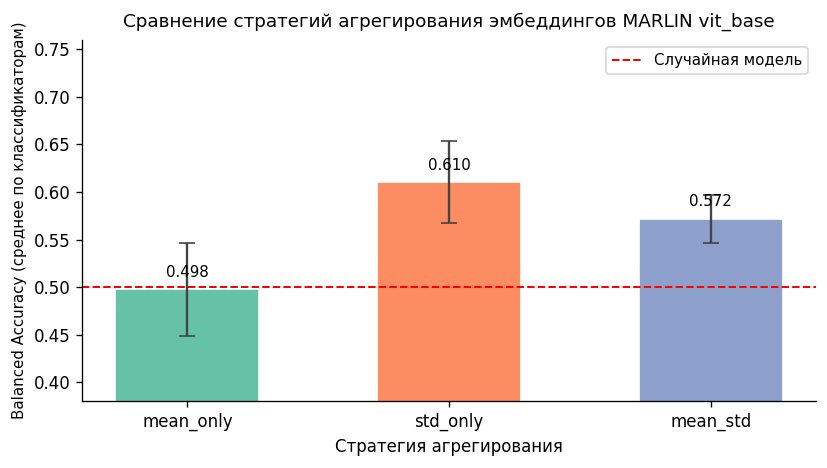

Сохранено: figures/fig_02_aggregation_comparison.png


In [9]:
feat_stats = (
    marlin_base
    .groupby("features")["bal_acc"]
    .agg(["mean", "std"])
    .reindex(feat_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))
palette = plt.cm.Set2.colors

bars = ax.bar(
    feat_stats["features"], feat_stats["mean"],
    yerr=feat_stats["std"], capsize=5,
    color=palette[:len(feat_stats)],
    width=0.55, edgecolor="white",
    error_kw=dict(elinewidth=1.4, ecolor="#444"),
)
ax.axhline(0.5, color="red", linestyle="--", lw=1.2, label="Случайная модель")

for bar, v in zip(bars, feat_stats["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Стратегия агрегирования", fontsize=10)
ax.set_ylabel("Balanced Accuracy (среднее по классификаторам)", fontsize=9)
ax.set_title("Сравнение стратегий агрегирования эмбеддингов MARLIN vit_base", fontsize=11, pad=8)
ax.legend(fontsize=9)
ax.set_ylim(0.38, 0.76)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_02_aggregation_comparison.png", bbox_inches="tight")
plt.show()
print("Сохранено: figures/fig_02_aggregation_comparison.png")

## 4. Стабильность по фолдам

Точные боксплоты требуют пер-фолдовых данных (не сохранены в CSV).  
Здесь: bar chart mean ± std по лучшим конфигурациям — точное отображение данных из CSV.

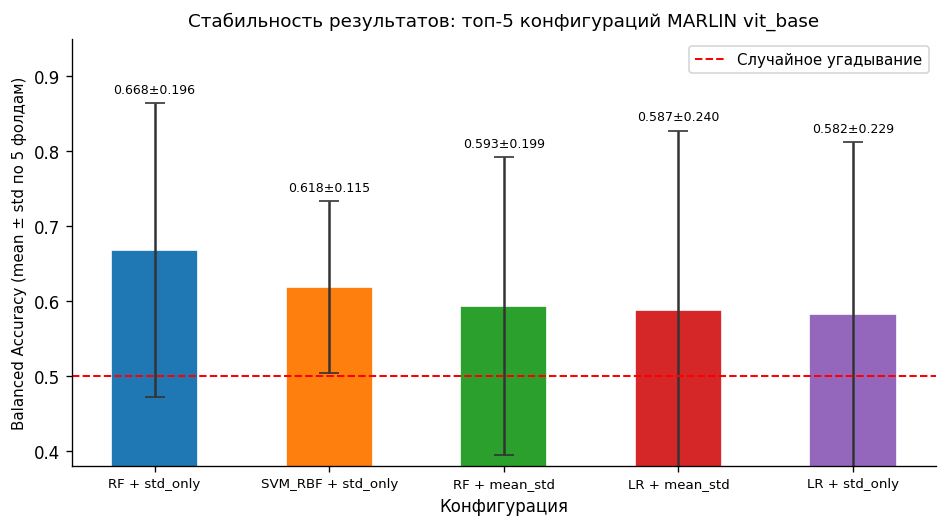

Сохранено: figures/fig_05_fold_stability.png


In [10]:
top5 = marlin_base.sort_values("bal_acc", ascending=False).head(5).copy()
top5["config"] = top5["classifier"] + " + " + top5["features"]

fig, ax = plt.subplots(figsize=(8, 4.5))
palette5 = plt.cm.tab10.colors

bars = ax.bar(
    top5["config"], top5["bal_acc"],
    yerr=top5["std"], capsize=6,
    color=palette5[:len(top5)],
    width=0.5, edgecolor="white",
    error_kw=dict(elinewidth=1.5, ecolor="#333"),
)
ax.axhline(0.5, color="red", linestyle="--", lw=1.2, label="Случайное угадывание")

for bar, v, s in zip(bars, top5["bal_acc"], top5["std"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + s + 0.01,
            f"{v:.3f}±{s:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_ylim(0.38, 0.95)
ax.set_xlabel("Конфигурация", fontsize=10)
ax.set_ylabel("Balanced Accuracy (mean ± std по 5 фолдам)", fontsize=9)
ax.set_title("Стабильность результатов: топ-5 конфигураций MARLIN vit_base", fontsize=11, pad=8)
ax.tick_params(axis="x", labelsize=8)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_05_fold_stability.png", bbox_inches="tight")
plt.show()
print("Сохранено: figures/fig_05_fold_stability.png")

## 5. Сравнение всех моделей

Лицевые энкодеры (MARLIN) vs общие (VideoMAE, ViViT, TimeSformer).

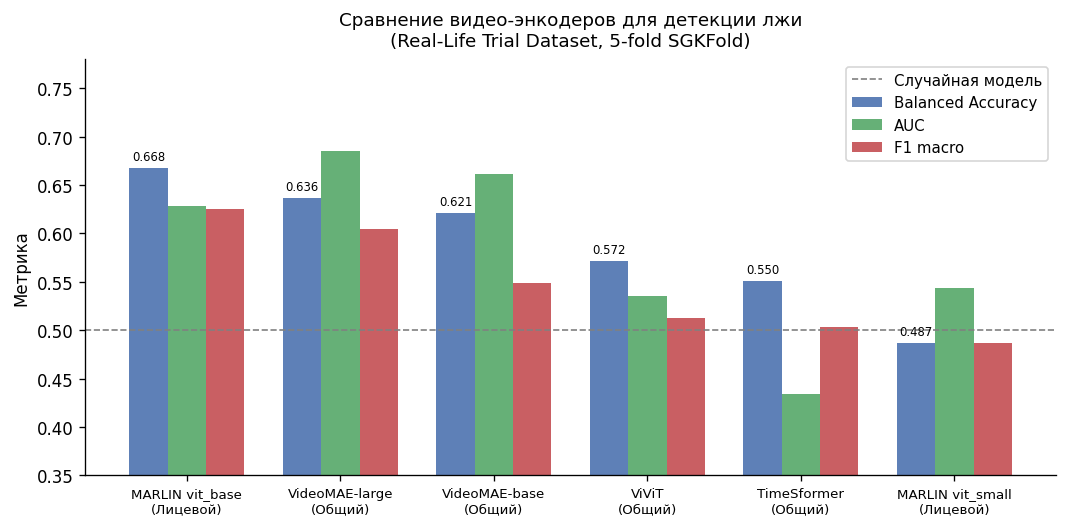

Сохранено: figures/fig_all_models_full.png


In [11]:
df_all = all_models.sort_values("BA", ascending=False).reset_index(drop=True)

color_map = {"Лицевой": "#4C72B0", "Общий": "#DD8452"}
colors = [color_map[t] for t in df_all["Тип"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(df_all))
w = 0.25

bars_ba  = ax.bar(x - w, df_all["BA"],  width=w, color="#4C72B0", label="Balanced Accuracy", alpha=0.9)
bars_auc = ax.bar(x,     df_all["AUC"], width=w, color="#55A868", label="AUC",               alpha=0.9)
bars_f1  = ax.bar(x + w, df_all["F1"],  width=w, color="#C44E52", label="F1 macro",          alpha=0.9)

ax.axhline(0.5, color="grey", linestyle="--", lw=1.0, label="Случайная модель")

for bar in bars_ba:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=7)

# подписи типа модели под осью X
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{m}\n({t})" for m, t in zip(df_all["Модель"], df_all["Тип"])],
    fontsize=8
)
ax.set_ylabel("Метрика", fontsize=10)
ax.set_title("Сравнение видео-энкодеров для детекции лжи\n(Real-Life Trial Dataset, 5-fold SGKFold)",
             fontsize=11, pad=8)
ax.set_ylim(0.35, 0.78)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_all_models_full.png", bbox_inches="tight")
plt.show()
print("Сохранено: figures/fig_all_models_full.png")

## 6. Лицевые vs Общие энкодеры

Сравнение двух групп моделей по Balanced Accuracy.

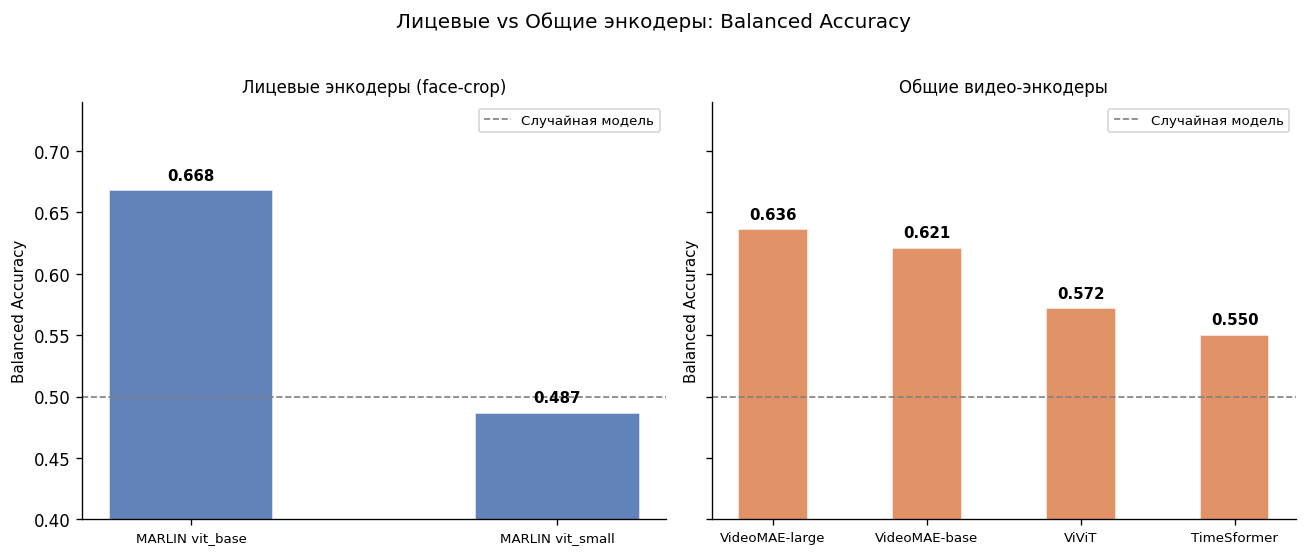

Сохранено: figures/fig_face_vs_general.png


In [12]:
face_models    = df_all[df_all["Тип"] == "Лицевой"]
general_models = df_all[df_all["Тип"] == "Общий"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, group_df, title, color in [
    (axes[0], face_models,    "Лицевые энкодеры (face-crop)",  "#4C72B0"),
    (axes[1], general_models, "Общие видео-энкодеры",           "#DD8452"),
]:
    bars = ax.bar(
        group_df["Модель"], group_df["BA"],
        color=color, width=0.45, alpha=0.88, edgecolor="white",
    )
    ax.axhline(0.5, color="grey", linestyle="--", lw=1.0, label="Случайная модель")
    for bar, v in zip(bars, group_df["BA"]):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.006,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=10, pad=6)
    ax.set_ylabel("Balanced Accuracy", fontsize=9)
    ax.set_ylim(0.40, 0.74)
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(fontsize=8)

fig.suptitle("Лицевые vs Общие энкодеры: Balanced Accuracy", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_face_vs_general.png", bbox_inches="tight")
plt.show()
print("Сохранено: figures/fig_face_vs_general.png")

## 7. Итоговая таблица топ конфигураций MARLIN vit_base

In [13]:
top10 = marlin_base.sort_values("bal_acc", ascending=False).copy()
top10.columns = ["Стратегия", "Классификатор", "Balanced Acc", "Std (по фолдам)", "AUC"]
for col in ["Balanced Acc", "Std (по фолдам)", "AUC"]:
    top10[col] = top10[col].map("{:.4f}".format)

print("=== Топ конфигураций MARLIN vit_base ===")
print(top10.to_string(index=False))

=== Топ конфигураций MARLIN vit_base ===
Стратегия Классификатор Balanced Acc Std (по фолдам)    AUC
 std_only            RF       0.6676          0.1962 0.4816
 std_only       SVM_RBF       0.6179          0.1147 0.5237
 mean_std            RF       0.5927          0.1987 0.4790
 mean_std            LR       0.5871          0.2398 0.4497
 std_only            LR       0.5819          0.2295 0.5398
 std_only       SVM_lin       0.5737          0.2332 0.4987
 mean_std       SVM_lin       0.5712          0.2444 0.4438
mean_only       SVM_lin       0.5476          0.1765 0.4018
 mean_std       SVM_RBF       0.5359          0.1271 0.4589
mean_only            LR       0.5316          0.1745 0.3777
mean_only            RF       0.4615          0.1102 0.3722
mean_only       SVM_RBF       0.4500          0.1459 0.3924


## 8. Сводная таблица всех моделей

In [14]:
print("=== Сравнение всех энкодеров ===")
summary = all_models.sort_values("BA", ascending=False).copy()
for col in ["BA", "AUC", "F1"]:
    summary[col] = summary[col].map("{:.4f}".format)
print(summary.to_string(index=False))

=== Сравнение всех энкодеров ===
          Модель     Тип  dim     BA    AUC     F1
 MARLIN vit_base Лицевой  768 0.6680 0.6280 0.6250
  VideoMAE-large   Общий 1024 0.6362 0.6853 0.6043
   VideoMAE-base   Общий  768 0.6210 0.6610 0.5490
           ViViT   Общий  768 0.5718 0.5352 0.5122
     TimeSformer   Общий  768 0.5505 0.4344 0.5032
MARLIN vit_small Лицевой  384 0.4870 0.5440 0.4870


---
**Выводы:**
- Лучшая конфигурация: **RF + std_only** → Balanced Accuracy 0.668
- Стратегия **std_only** систематически превосходит **mean_only**, подтверждая гипотезу о большей информативности вариативности мимики
- Лицевой энкодер MARLIN vit_base превосходит общие видео-энкодеры несмотря на меньший dim (768 vs 1024 у VideoMAE-large)
- Высокий std по фолдам (0.10–0.24) — следствие малого датасета (119 видео, 54 субъекта)